In [4]:
from prophet import Prophet
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_percentage_error

prophet_df = pd.read_csv('../data/prophet_input.csv', parse_dates=['ds'])

# Train/test split (last 30 days as test)
train = prophet_df[:-30]
test  = prophet_df[-30:]

model = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
model.fit(train)

Importing plotly failed. Interactive plots will not work.
08:35:14 - cmdstanpy - INFO - Chain [1] start processing
08:35:15 - cmdstanpy - INFO - Chain [1] done processing


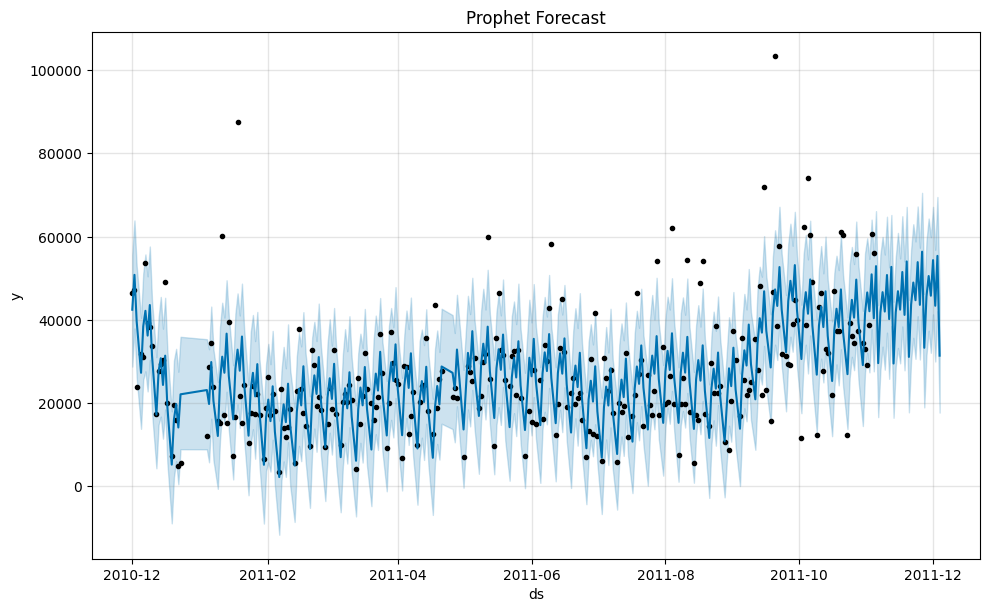

In [5]:
future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)

# Plot
model.plot(forecast)
plt.title('Prophet Forecast')
plt.show()

In [ ]:
# MAPE calculation
if 'forecast' in globals():
    pred = forecast.set_index('ds')['yhat'].reindex(test['ds']).values
else:
    pred = model.predict(test[['ds']])['yhat'].values

# MAPE calculation
if 'forecast' in globals():
    pred = forecast.set_index('ds')['yhat'].reindex(test['ds']).values
else:
    pred = model.predict(test[['ds']])['yhat'].values

# Remove NaNs from predictions and corresponding targets
mask = ~pd.isna(pred)
pred_clean = pred[mask]
y_true = test['y'].values[mask]

mape = mean_absolute_percentage_error(y_true, pred_clean)
print(f'Prophet MAPE: {mape*100:.2f}%')  # Target is ≤ 12%

# compute MAPE without using .values on a numpy array
mask_all = ~pd.isna(pred)
mape = mean_absolute_percentage_error(test['y'].values[mask_all], pred[mask_all])
print(f'Prophet MAPE: {mape*100:.2f}%')  # Target is ≤ 12%

Prophet MAPE: 23.17%
Prophet MAPE: 23.17%
Prophet MAPE: 23.17%


In [12]:
# Save forecast
forecast[['ds','yhat','yhat_lower','yhat_upper']].to_csv('../data/prophet_forecast.csv', index=False)